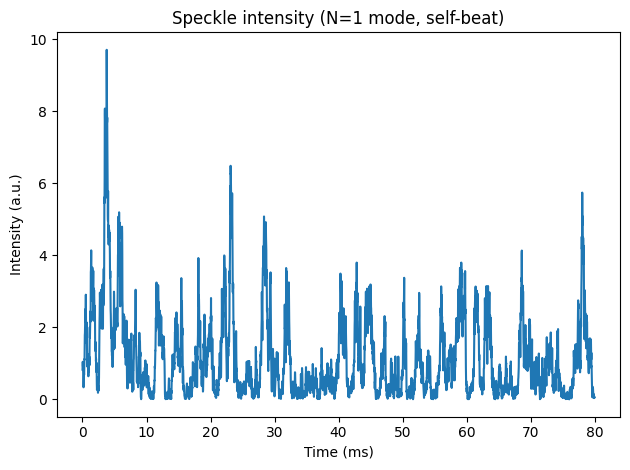

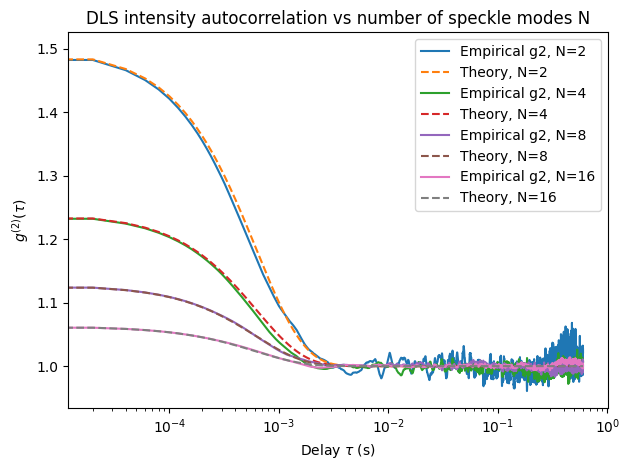

In [21]:
# DLS-like simulation: show g2(τ) for different numbers of speckle modes (N)
# and use a log x-axis for the delay. Uses a complex Gaussian AR(1) field
# with g1(τ)=exp(-Γτ). Intensity is the sum of N independent speckle modes.
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(10)

# Sampling and dynamics
fs = 50_000.0              # samples/s
dt = 1.0/fs
Gamma = 800.0              # [1/s]; field decorrelation rate
rho = np.exp(-Gamma*dt)    # AR(1) coefficient
sigma = np.sqrt(1 - rho**2)# to keep unit variance

# Simulation length
Nsamp = 60_000             # total samples (~1.2 s)

# Helper: generate one complex AR(1) field of length Nsamp
def complex_ar1(N):
    xi = (rng.normal(size=N) + 1j*rng.normal(size=N)) / np.sqrt(2.0)
    E = np.empty(N, dtype=np.complex128)
    E[0] = xi[0]
    for n in range(1, N):
        E[n] = rho*E[n-1] + sigma*xi[n]
    return E

# Compute g2 for a given number of independent speckle modes N_modes
def g2_for_modes(N_modes, maxlag):
    # Sum intensities from independent modes (incoherent sum at the detector)
    I = np.zeros(Nsamp, dtype=np.float64)
    for _ in range(N_modes):
        E = complex_ar1(Nsamp)
        I += np.abs(E)**2
    # Normalize intensity to unit mean for easier comparison across N
    I /= I.mean()
    g2 = np.empty(maxlag+1)
    for k in range(maxlag+1):
        g2[k] = np.mean(I[:Nsamp-k] * I[k:])
    return g2

# Delays to evaluate
maxlag = 30000                         # up to 0.6 s
taus = np.arange(maxlag+1)*dt

# Explore different numbers of speckle modes N
N_list = [2, 4, 8, 16]

# Plot a short intensity segment for N=1 (just to visualize the raw trace)
E_demo = complex_ar1(4000)  # ~80 ms
I_demo = np.abs(E_demo)**2
t_ms = np.arange(I_demo.size)*dt*1e3
plt.figure()
plt.plot(t_ms, I_demo)
plt.xlabel("Time (ms)")
plt.ylabel("Intensity (a.u.)")
plt.title("Speckle intensity (N=1 mode, self-beat)")
plt.tight_layout()

# Now compute and plot g2(τ) for different N, with log x-axis
plt.figure()
for N_modes in N_list:
    g2_vals = g2_for_modes(N_modes, maxlag)
    beta_est = g2_vals[0] - 1.0
    g2_th = 1.0 + beta_est * np.exp(-2.0*Gamma*taus)  # Siegert (homodyne)
    plt.plot(taus, g2_vals, label=f"Empirical g2, N={N_modes}")
    plt.plot(taus, g2_th, linestyle="--", label=f"Theory, N={N_modes}")
plt.xscale("log")
plt.xlabel("Delay $\\tau$ (s)")
plt.ylabel("$g^{(2)}(\\tau)$")
plt.title("DLS intensity autocorrelation vs number of speckle modes N")
plt.legend()
plt.tight_layout()


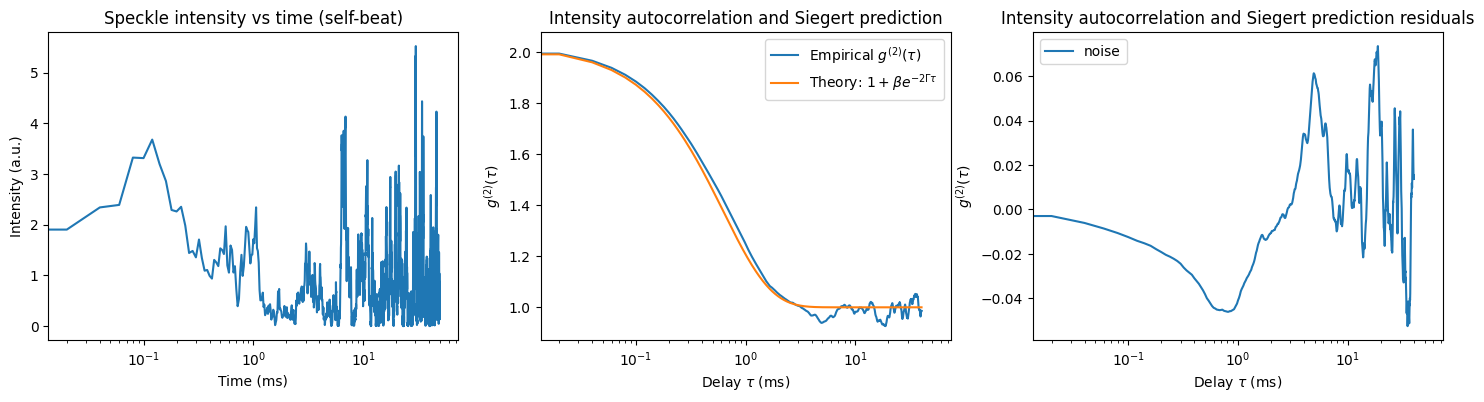

In [22]:
# Toy simulation of a DLS-like speckle signal (homodyne/self-beat) and its autocorrelation
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(8)

# Parameters (roughly DLS-like)
fs = 50_000.0         # samples per second
dt = 1.0/fs
Gamma = 800.0         # field decorrelation rate [1/s] -> tau_c = 1/Gamma
N = 50_000            # total samples (~0.5 s)

rho = np.exp(-Gamma*dt)                  # AR(1) coefficient to get g1(tau)=exp(-Gamma*tau)
sigma = np.sqrt(1 - rho**2)              # to keep unit variance in steady state

# Complex circular Gaussian field with exponential autocorrelation (AR(1) in discrete time)
xi = (rng.normal(size=N) + 1j*rng.normal(size=N)) / np.sqrt(2.0)
E = np.empty(N, dtype=np.complex128)
E[0] = xi[0]
for n in range(1, N):
    E[n] = rho*E[n-1] + sigma*xi[n]

# Intensity (homodyne/self-beat): I(t) = |E(t)|^2
I = np.abs(E)**2

# Empirical g2(tau) = <I(t) I(t+tau)> / <I>^2
maxlag = 2000  # ~40 ms
g2 = np.empty(maxlag+1)
meanI = I.mean()
for k in range(maxlag+1):
    g2[k] = np.mean(I[:N-k] * I[k:]) / (meanI**2)

taus = np.arange(maxlag+1) * dt
beta_est = g2[0] - 1.0  # ideal homodyne: g2(0) = 1 + beta

g2_theory = 1.0 + beta_est * np.exp(-2.0*Gamma*taus)  # Siegert for homodyne

# Plot a short segment of intensity
segment = slice(0, 2500)  # first 50 ms
t_ms = np.arange(segment.stop - segment.start) * dt * 1e3

# Plot g2 and the theoretical exponential from Siegert
fig = plt.figure(figsize=(18, 4))
ax0, ax1, ax2 = fig.subplots(1, 3, sharex=True)
ax0.plot(t_ms, I[segment])
ax0.set_xlabel("Time (ms)")
ax0.set_ylabel("Intensity (a.u.)")
ax0.set_title("Speckle intensity vs time (self-beat)")

ax1.plot(taus*1e3, g2, label="Empirical $g^{(2)}(\\tau)$")
ax1.plot(taus*1e3, g2_theory, label="Theory: $1 + \\beta e^{-2\\Gamma\\tau}$")
ax1.set_xlabel("Delay $\\tau$ (ms)")
ax1.set_ylabel("$g^{(2)}(\\tau)$")
ax1.set_title("Intensity autocorrelation and Siegert prediction")
ax1.legend()
ax2.plot(taus*1e3, g2_theory - g2, label="noise")
ax2.set_xlabel("Delay $\\tau$ (ms)")
ax2.set_ylabel("$g^{(2)}(\\tau)$")
ax2.set_title("Intensity autocorrelation and Siegert prediction residuals")
ax2.legend()
ax1.set_xscale("log")


In [ ]:
# bayesian learning MCMC with empirical 
# https://www.sciencedirect.com/science/article/pii/S0169743911000530
    # citations on google scholar all chinese
    # https://scholar.google.com/scholar?cites=11151029750662952219&as_sdt=4005&sciodt=0,6&hl=en




# extension of previous
# https://ieeexplore.ieee.org/document/6952465
# cites first one
    # https://www.eurasip.org/Proceedings/Eusipco/Eusipco2014/HTML/papers/1569926795.pdf - open access version




# possibly about noise generation?
# https://pmc.ncbi.nlm.nih.gov/articles/PMC4523555/

